# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 19 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada UNet

## 1. Importe de librerias

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import os
import zipfile
import shutil
!pip install seaborn
import seaborn as sns
import datetime
!pip install opencv-python
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, GlobalAveragePooling2D

!pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-21 19:58:44.945809


## 2. Definción de Rutas y Parámetros

In [6]:
data_dir = 'Datos Finales'  # Reemplaza con la ruta real
metadata_file = 'Metadatos_Finales.csv' # Reemplaza con la ruta real
image_height = 128
image_width = 128
batch_size = 32
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [8]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    metadata = metadata.rename(columns={'Planta_Estado': 'Planta_Estado_Español'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Estado_Español' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta_Estado_Español'.")
    class_names = metadata['Planta_Estado_Español'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 18 clases: ['Yuca_Enferma', 'Yuca_Saludable', 'Fresa_Saludable', 'Papa_Enferma', 'Maíz_Saludable', 'Tomate_Enferma', 'Manzana_Enferma', 'Maíz_Enferma', 'Tomate_Saludable', 'Manzana_Saludable', 'Fresa_Enferma', 'Papa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Fríjol_Enferma', 'Coliflor_Saludable', 'Fríjol_Saludable', 'Pepino Cohombro_Enferma']


In [9]:
metadata.Planta_Estado_Español.value_counts()

Planta_Estado_Español
Yuca_Enferma                 18820
Tomate_Enferma               16569
Maíz_Enferma                  2690
Yuca_Saludable                2577
Papa_Enferma                  2000
Manzana_Saludable             1645
Tomate_Saludable              1591
Manzana_Enferma               1529
Maíz_Saludable                1162
Fresa_Enferma                 1109
Fríjol_Enferma                 868
Fresa_Saludable                456
Coliflor_Enferma               450
Fríjol_Saludable               428
Pepino Cohombro_Enferma        350
Pepino Cohombro_Saludable      341
Coliflor_Saludable             206
Papa_Saludable                 152
Name: count, dtype: int64

In [10]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Estado_Español'])
train.shape, test.shape

((42354, 12), (10589, 12))

In [11]:
train.head()

,Dataset,Carpeta,image_id,Planta,Enfermedad Inglés,Saludable,Planta_Estado_Inglés,Planta Español,Planta_Estado_Español,Nombre traducido por GPT,Nombre Coloquial en Colombia,Nombre Coloquial en TV
36463,PlantVillage,Tomato___Tomato_Yellow_Leaf_Curl_Virus,32207a2c-d924-43e7-b466-94832710049d___UF.GRC_...,Tomato,Tomato_Yellow_Leaf_Curl_Virus,No,Tomato_sick,Tomate,Tomate_Enferma,Virus del rizado amarillo,Hojas enrolladas del tomate,Le falta agua
40664,PlantVillage,Tomato___Tomato_Yellow_Leaf_Curl_Virus,87fd49d2-d1b0-4e33-9443-1de82d2c19a1___YLCV_GC...,Tomato,Tomato_Yellow_Leaf_Curl_Virus,No,Tomato_sick,Tomate,Tomate_Enferma,Virus del rizado amarillo,Hojas enrolladas del tomate,Le falta agua
43174,PlantVillage,Tomato___Spider_mites Two-spotted_spider_mite,2fb77f60-ae5b-40c4-b6fb-3c90ac55ccd4___Com.G_S...,Tomato,Spider_mites Two-spotted_spider_mite,No,Tomato_sick,Tomate,Tomate_Enferma,Ácaros / Arañita roja,Polvillo rojo,Deshidratada
25436,PlantVillage,Potato___Late_blight,0c2628d4-8d64-48a9-a157-19a9c902e304___RS_LB 4...,Potato,Late_blight,No,Potato_sick,Papa,Papa_Enferma,Tizón tardío,Pudrición de la papa,Quemada
853,Cassava Leaf Disease Classification,Cassava,1146671365.jpg,Cassava,Cassava Brown Streak Disease (CBSD),No,Cassava_sick,Yuca,Yuca_Enferma,Estría marrón de la yuca,Venas marrones de la yuca,Exceso de humedad


In [12]:
sample = train.sample(5)  # ejemplo común
print(sample)

                                    Dataset  \
38094                          PlantVillage   
48211                          PlantVillage   
9291   Cassava Leaf Disease Classification    
4738   Cassava Leaf Disease Classification    
8741   Cassava Leaf Disease Classification    

                                      Carpeta  \
38094  Tomato___Tomato_Yellow_Leaf_Curl_Virus   
48211                         Apple___healthy   
9291                                  Cassava   
4738                                  Cassava   
8741                                  Cassava   

                                                image_id   Planta  \
38094  bd7593bc-0d9e-4579-9648-685d94e8bd44___UF.GRC_...   Tomato   
48211  eb1b7162-9f7a-4bb7-b3fc-5dcaef541b55___RS_HL 6...    Apple   
9291                                      2645676271.jpg  Cassava   
4738                                       184437770.jpg  Cassava   
8741                                      2548839038.jpg  Cassava   

       

In [13]:
print(sample.columns)

Index(['Dataset', 'Carpeta', 'image_id', 'Planta', 'Enfermedad Inglés',
       'Saludable', 'Planta_Estado_Inglés', 'Planta Español',
       'Planta_Estado_Español', 'Nombre traducido por GPT',
       'Nombre Coloquial en Colombia', 'Nombre Coloquial en TV'],
      dtype='object')


## 4. Crear un generador de datos

In [15]:
df_subset = train.sample(frac=0.50, random_state=42)  # Solo 50% de los datos para entrenamiento rápido
df_subset.head()

,Dataset,Carpeta,image_id,Planta,Enfermedad Inglés,Saludable,Planta_Estado_Inglés,Planta Español,Planta_Estado_Español,Nombre traducido por GPT,Nombre Coloquial en Colombia,Nombre Coloquial en TV
46571,PlantVillage,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,9a59a663-089f-4722-8bb5-937f18978888___RS_GLSp...,Corn_(maize),Cercospora_leaf_spot Gray_leaf_spot,No,Corn_(maize)_sick,Maíz,Maíz_Enferma,Mancha gris,Pinta gris,Pudrición
1360,Cassava Leaf Disease Classification,Cassava,1237914743.jpg,Cassava,Cassava Mosaic Disease (CMD),No,Cassava_sick,Yuca,Yuca_Enferma,Enfermedad del mosaico de la yuca,Manchas amarillas en la yuca,Exceso de humedad
10951,Cassava Leaf Disease Classification,Cassava,2949633440.jpg,Cassava,Cassava Mosaic Disease (CMD),No,Cassava_sick,Yuca,Yuca_Enferma,Enfermedad del mosaico de la yuca,Manchas amarillas en la yuca,Exceso de humedad
6611,Cassava Leaf Disease Classification,Cassava,2184623119.jpg,Cassava,Cassava Mosaic Disease (CMD),No,Cassava_sick,Yuca,Yuca_Enferma,Enfermedad del mosaico de la yuca,Manchas amarillas en la yuca,Exceso de humedad
9946,Cassava Leaf Disease Classification,Cassava,2768458456.jpg,Cassava,Cassava Mosaic Disease (CMD),No,Cassava_sick,Yuca,Yuca_Enferma,Enfermedad del mosaico de la yuca,Manchas amarillas en la yuca,Exceso de humedad


In [16]:
df_subset.shape

(21177, 12)

In [17]:
# Crear el generador de imágenes
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255
)

train_generator = datagen.flow_from_dataframe(
    dataframe=df_subset,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=df_subset,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 16940 validated image filenames belonging to 18 classes.
Found 4235 validated image filenames belonging to 18 classes.


In [18]:
print(train['Planta_Estado_Español'].value_counts())
print(f"Total clases: {train['Planta_Estado_Español'].nunique()}")


Planta_Estado_Español
Yuca_Enferma                 15056
Tomate_Enferma               13255
Maíz_Enferma                  2152
Yuca_Saludable                2061
Papa_Enferma                  1600
Manzana_Saludable             1316
Tomate_Saludable              1273
Manzana_Enferma               1223
Maíz_Saludable                 930
Fresa_Enferma                  887
Fríjol_Enferma                 694
Fresa_Saludable                365
Coliflor_Enferma               360
Fríjol_Saludable               342
Pepino Cohombro_Enferma        280
Pepino Cohombro_Saludable      273
Coliflor_Saludable             165
Papa_Saludable                 122
Name: count, dtype: int64
Total clases: 18


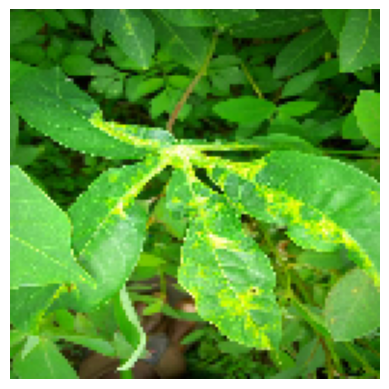

In [19]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np

img_path = os.path.join(data_dir, metadata["image_id"][20])
img = image.load_img(img_path, target_size=(image_height, image_width))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

## 5. Definición del modelo U-Net para clasificación

In [21]:
epochs=10
steps_per_epoch = len(train)*0.8 / batch_size
validation_steps = len(train)*0.2 / batch_size

In [22]:
# DEFINIR EL MODELO U-NET MODIFICADO PARA CLASIFICACIÓN
def unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    # Clasificación
    gap = GlobalAveragePooling2D()(c7)
    outputs = Dense(num_classes, activation='softmax')(gap)

    model = Model(inputs=inputs, outputs=outputs)
    return model


# CREAR Y COMPILAR EL MODELO
model = unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()  # Muestra la arquitectura


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,947,442 (7.43 MB)

 Trainable params: 1,947,442 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # Monitorea la pérdida en validación
    patience=5,             # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos
    verbose=1
)

## 6. Entrenamiento del Modelo

In [25]:
#Entrenamiento
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    steps_per_epoch=int(steps_per_epoch),
    validation_steps=int(validation_steps),
    callbacks=[early_stop]
)

Epoch 1/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1510s 1s/step - accuracy: 0.5567 - loss: 1.6346 - val_accuracy: 0.6987 - val_loss: 1.0917
Epoch 2/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1528s 1s/step - accuracy: 0.7225 - loss: 0.9897 - val_accuracy: 0.7263 - val_loss: 0.9338
Epoch 3/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1520s 1s/step - accuracy: 0.7618 - loss: 0.7613 - val_accuracy: 0.7745 - val_loss: 0.6644
Epoch 4/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1531s 1s/step - accuracy: 0.8077 - loss: 0.6010 - val_accuracy: 0.8149 - val_loss: 0.6016
Epoch 5/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1532s 1s/step - accuracy: 0.8375 - loss: 0.5093 - val_accuracy: 0.8531 - val_loss: 0.4868
Epoch 6/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1533s 1s/step - accuracy: 0.8611 - loss: 0.4359 - val_accuracy: 0.8571 - val_loss: 0.4478
Epoch 7/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1532s 1s/step - accuracy: 0.8732 - loss: 0.3934 - val_accuracy: 0.8560 - val_loss: 0.4420
Epoch 8/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1529s 1s/step - accuracy: 0.8786 -

In [26]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-22 00:13:20.001966
Duración: 4:14:35.056157


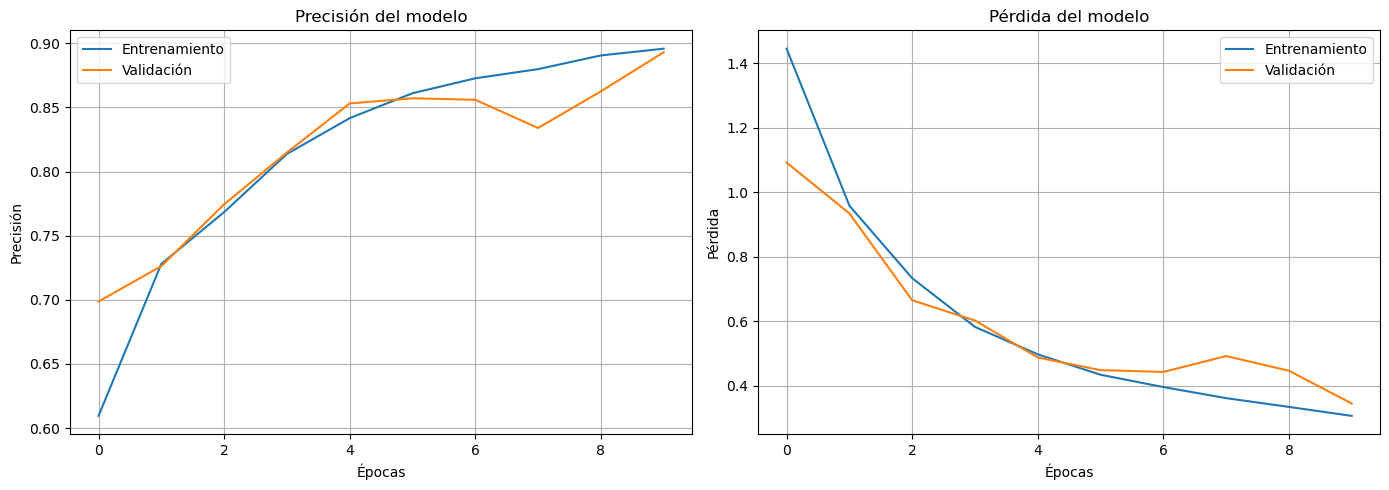

In [27]:
import matplotlib.pyplot as plt

# 1. Crear la figura
plt.figure(figsize=(14, 5))

# 2. Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# 3. Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# 4. Mostrar
plt.tight_layout()
plt.show()


In [28]:
print(test.columns.tolist())

['Dataset', 'Carpeta', 'image_id', 'Planta', 'Enfermedad Inglés', 'Saludable', 'Planta_Estado_Inglés', 'Planta Español', 'Planta_Estado_Español', 'Nombre traducido por GPT', 'Nombre Coloquial en Colombia', 'Nombre Coloquial en TV']


In [29]:
epochs = list(range(1, 11))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        1.444995         1.091662           0.609563   
1      2        0.958021         0.933842           0.728040   
2      3        0.733063         0.664361           0.768418   
3      4        0.581751         0.601618           0.813754   
4      5        0.496618         0.486833           0.841677   
5      6        0.433373         0.447759           0.861098   
6      7        0.395161         0.442043           0.872727   
7      8        0.360757         0.491369           0.879870   
8      9        0.333555         0.445861           0.890555   
9     10        0.305797         0.344120           0.895809   

   Validation  Accuracy  
0              0.698701  
1              0.726328  
2              0.774498  
3              0.814876  
4              0.853129  
5              0.857143  
6              0.855962  
7              0.834002  
8              0.862574  
9              0.893034  


In [30]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])

print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 0.30579739809036255
Pérdida final en Validation: 0.3441198766231537
Accuracy final en Train: 0.895808756351471
Accuracy final en Validation: 0.8930342197418213


In [34]:
#validación con datos de test

test_generator = datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta_Estado_Español",
                         target_size = (image_height,image_width),
                         batch_size = 1,
                         shuffle=False,
                         class_mode = "categorical")

Found 10589 validated image filenames belonging to 18 classes.


## 7. Testeo del Modelo

In [37]:
# Evaluar sobre el set de test
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator)) 

print(f'🔎 Pérdida en test: {test_loss:.4f}')
print(f'✅ Precisión en test: {test_accuracy:.2%}')


10589/10589 ━━━━━━━━━━━━━━━━━━━━ 300s 28ms/step - accuracy: 0.8972 - loss: 0.3312
🔎 Pérdida en test: 0.3324
✅ Precisión en test: 89.55%


In [41]:
# 1. Predecir clases sobre el test set
y_pred_probs = model.predict(test_generator)

# Convertir probabilidades a etiquetas (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas verdaderas
y_true = test_generator.classes

10589/10589 ━━━━━━━━━━━━━━━━━━━━ 312s 29ms/step


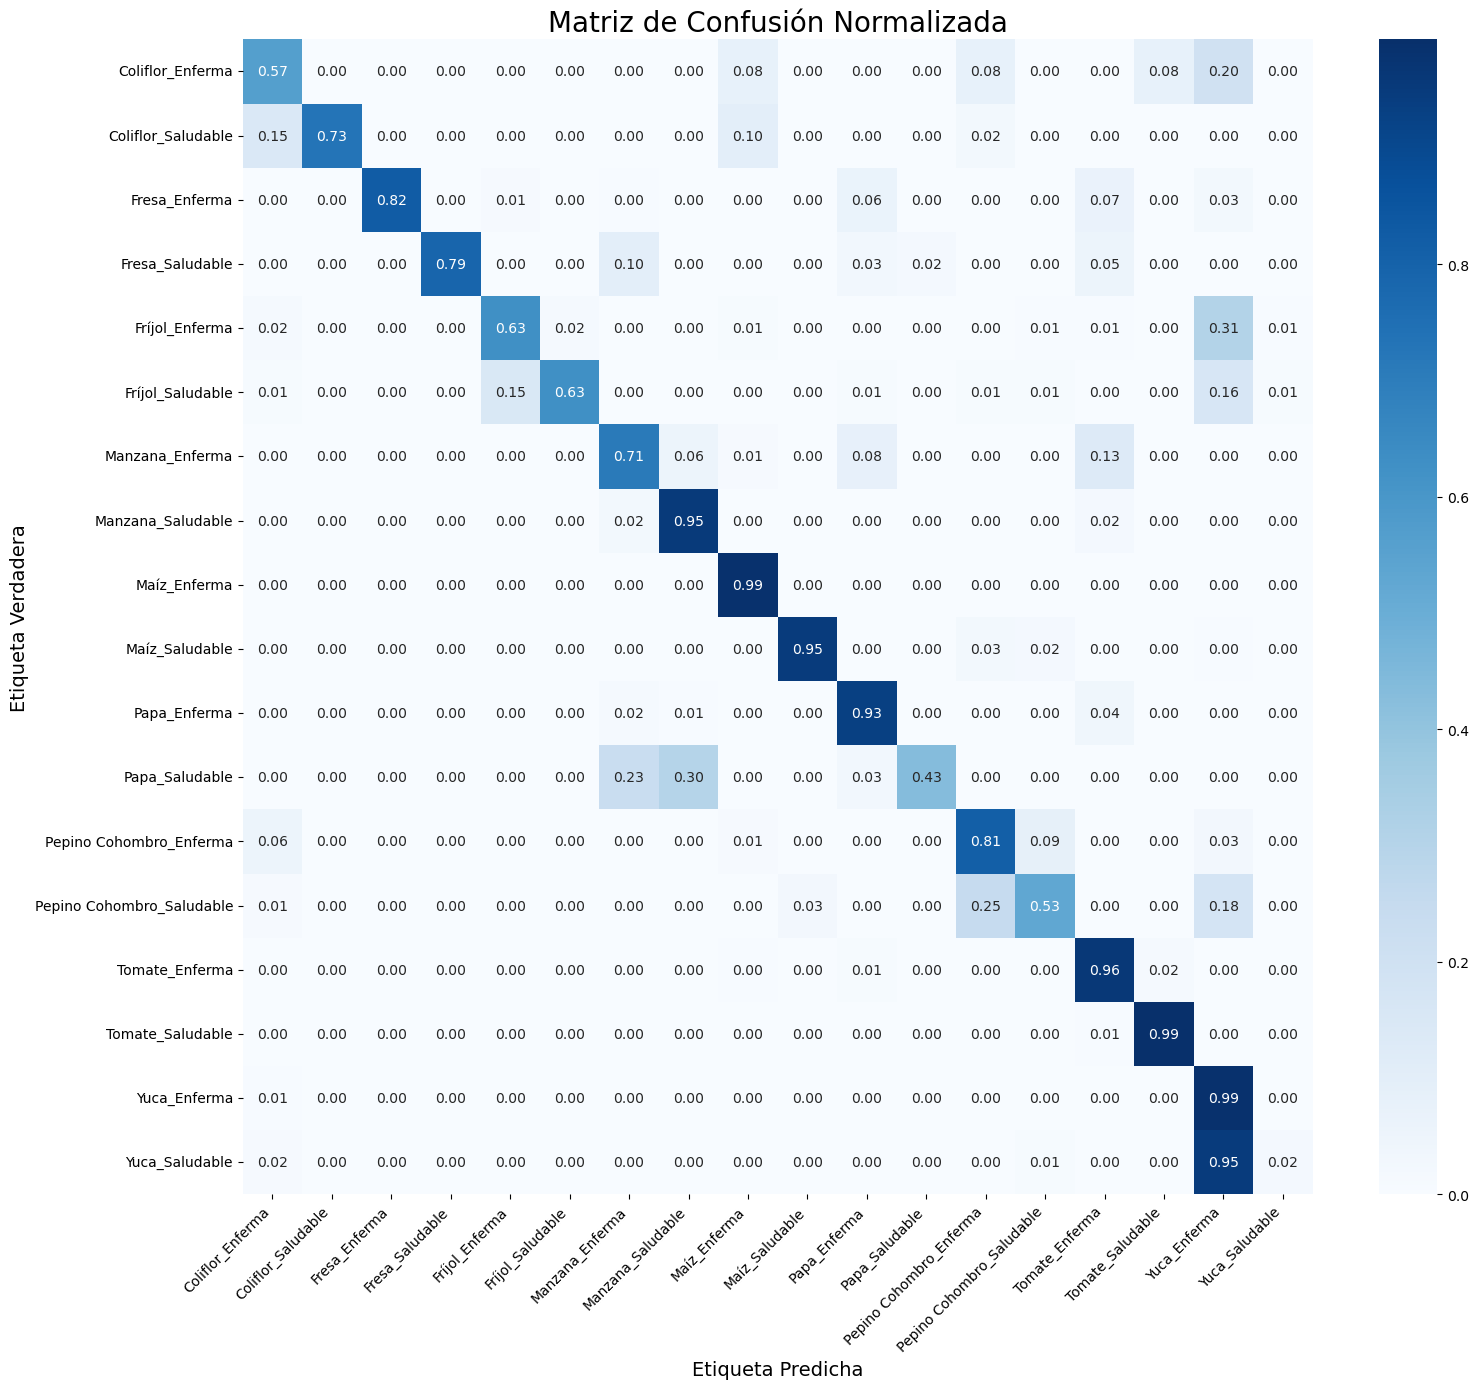


Reporte de Clasificación:
                           precision    recall  f1-score   support

         Coliflor_Enferma     0.5152    0.5667    0.5397        90
       Coliflor_Saludable     0.9677    0.7317    0.8333        41
            Fresa_Enferma     0.9892    0.8243    0.8993       222
          Fresa_Saludable     0.9863    0.7912    0.8780        91
           Fríjol_Enferma     0.7899    0.6264    0.6987       174
         Fríjol_Saludable     0.9310    0.6279    0.7500        86
          Manzana_Enferma     0.8258    0.7124    0.7649       306
        Manzana_Saludable     0.8870    0.9544    0.9195       329
             Maíz_Enferma     0.9399    0.9888    0.9638       538
           Maíz_Saludable     0.9821    0.9483    0.9649       232
             Papa_Enferma     0.8271    0.9325    0.8766       400
           Papa_Saludable     0.8667    0.4333    0.5778        30
  Pepino Cohombro_Enferma     0.6333    0.8143    0.7125        70
Pepino Cohombro_Saludable     0.58

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predecir clases sobre el test set
# Obtener las predicciones del modelo
#y_pred_probs = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Convertir probabilidades a etiquetas (argmax)
#_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas verdaderas
# Las verdaderas etiquetas están en test_generator.classes
#y_true = test_generator.classes

# 3. Obtener los nombres de las clases
class_labels = list(test_generator.class_indices.keys())

# 4. Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 5. Normalizar la matriz de confusión (opcional para mejor visualización)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 6. Graficar la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Reporte de clasificación (precisión, recall, f1-score por clase)
print('\nReporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))


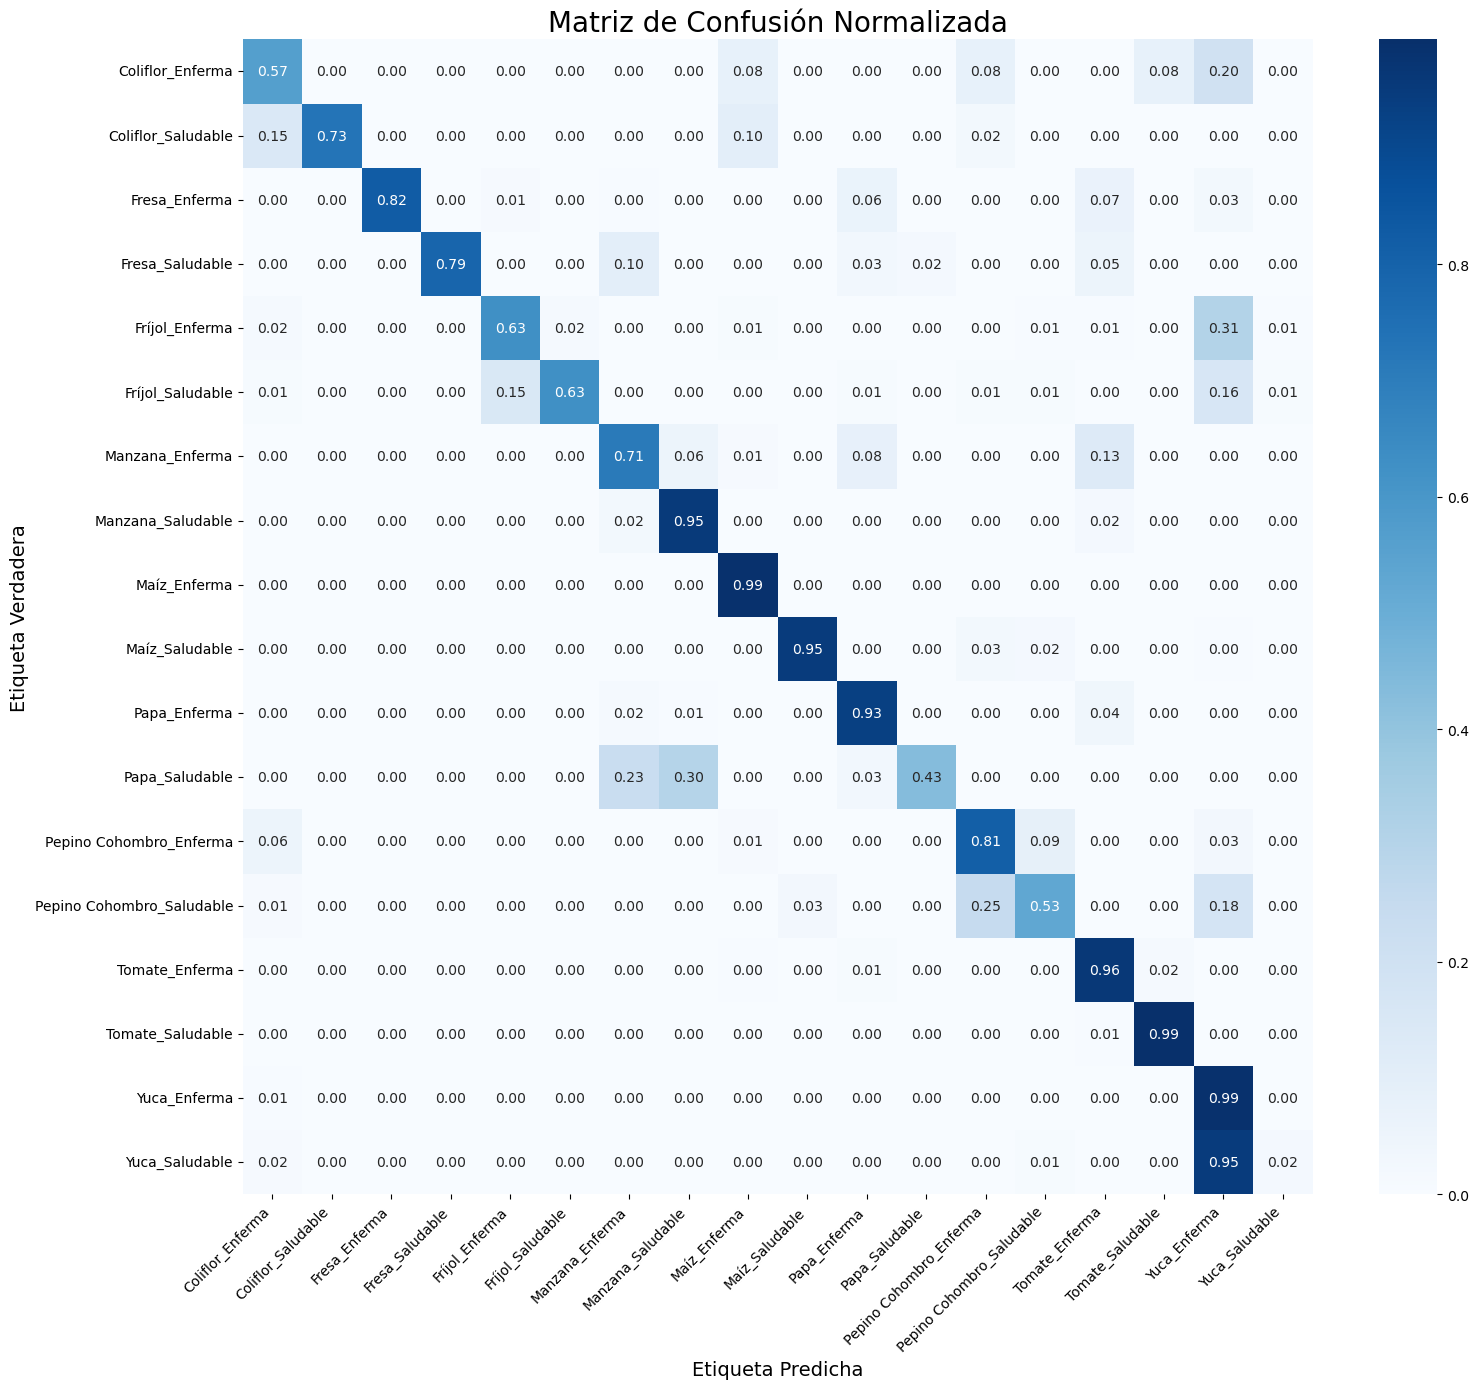

In [46]:
# 1. Guardar la figura de la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar el gráfico como imagen
plt.savefig(r'C:\Proyecto de grado\Modelos\matriz_confusion.png', dpi=300)
plt.show()


In [50]:
# 2. Guardar el reporte de clasificación en CSV

# Convertir el reporte a un diccionario
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convertirlo a DataFrame
report_df = pd.DataFrame(report).transpose()

# Guardar como CSV
report_df.to_csv('reporte_clasificacion_modelo16_UNet_Planta_Estado_sin_DataAugmentation_50per.csv', index=True)

print("✅ Reporte de clasificación guardado")


✅ Reporte de clasificación guardado


In [52]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8955


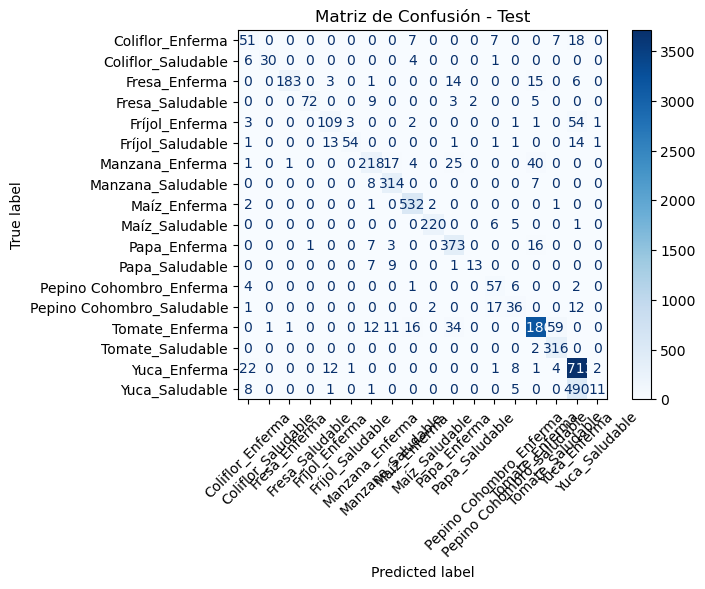

In [58]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


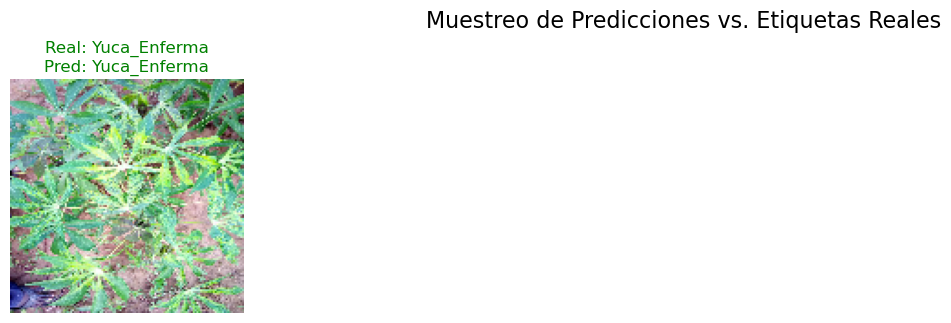

In [67]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

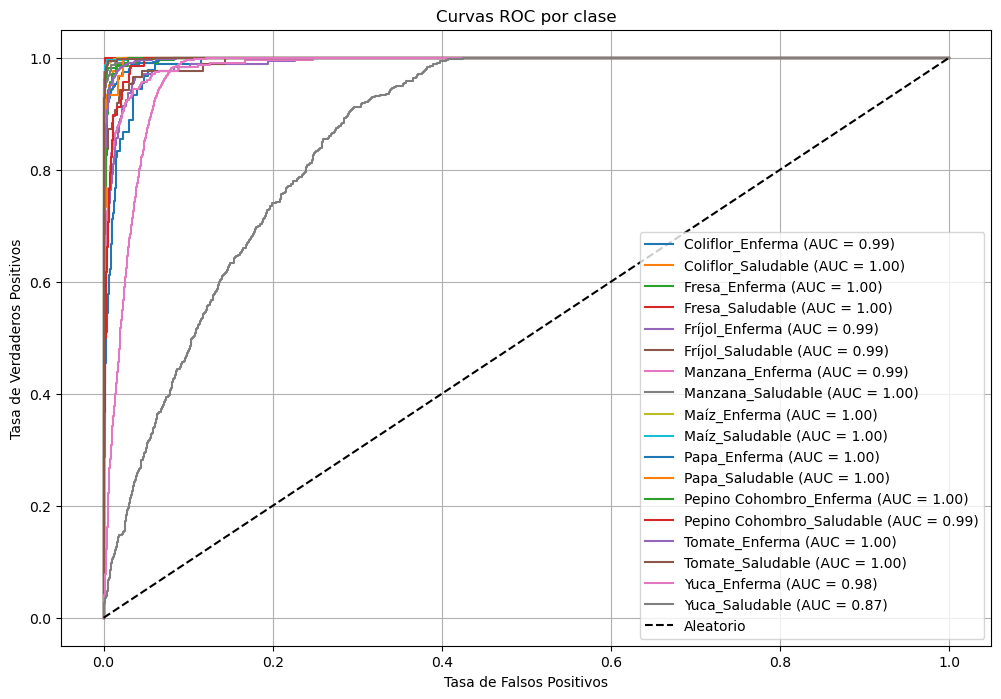

In [69]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [71]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.9884
AUC Micro promedio: 0.9966


In [73]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.8955
F1 Score (macro): 0.7643
F1 Score (micro): 0.8955
F1 Score (weighted): 0.8739

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.52      0.57      0.54        90
       Coliflor_Saludable       0.97      0.73      0.83        41
            Fresa_Enferma       0.99      0.82      0.90       222
          Fresa_Saludable       0.99      0.79      0.88        91
           Fríjol_Enferma       0.79      0.63      0.70       174
         Fríjol_Saludable       0.93      0.63      0.75        86
          Manzana_Enferma       0.83      0.71      0.76       306
        Manzana_Saludable       0.89      0.95      0.92       329
             Maíz_Enferma       0.94      0.99      0.96       538
           Maíz_Saludable       0.98      0.95      0.96       232
             Papa_Enferma       0.83      0.93      0.88       400
           Papa_Saludable       0.87      0.43      0.58       

## 8. Guardar el modelo entrenado

In [75]:
model.save('modelo_16_Unet_PlantaEstado_Sin_Data_Aug_50perc.h5')

In [77]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-22 04:33:43.980496
Duración: 8:34:59.034687


In [79]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_16_Unet_PlantaEstado_Sin_Data_Aug_50perc.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Coliflor_Enferma', 1: 'Coliflor_Saludable', 2: 'Fresa_Enferma', 3: 'Fresa_Saludable', 4: 'Fríjol_Enferma', 5: 'Fríjol_Saludable', 6: 'Manzana_Enferma', 7: 'Manzana_Saludable', 8: 'Maíz_Enferma', 9: 'Maíz_Saludable', 10: 'Papa_Enferma', 11: 'Papa_Saludable', 12: 'Pepino Cohombro_Enferma', 13: 'Pepino Cohombro_Saludable', 14: 'Tomate_Enferma', 15: 'Tomate_Saludable', 16: 'Yuca_Enferma', 17: 'Yuca_Saludable'}
